In [2]:
import pandas as pd 

df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

FileNotFoundError: [Errno 2] No such file or directory: '../data/WA_Fn-UseC_-Telco-Customer-Churn.csv'

In [1]:
import pandas as pd

df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv") 
df.head()


FileNotFoundError: [Errno 2] No such file or directory: '../data/WA_Fn-UseC_-Telco-Customer-Churn.csv'

In [1]:
import pandas as pd

df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")  # change name if different
df.head()



FileNotFoundError: [Errno 2] No such file or directory: '../data/WA_Fn-UseC_-Telco-Customer-Churn.csv'

In [2]:
df.shape
df.info
df.isna().sum()

NameError: name 'df' is not defined

In [3]:
import pandas as pd

df = pd.read_csv(r"D:\Churn_Analysis_Project\data\WA_Fn-UseC_-Telco-Customer-Churn.csv")  # use your exact path/name


In [4]:
df.shape 
df.info()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [5]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')
df['TotalCharges'].isna().sum()

df=df.dropna(subset=['TotalCharges'])

In [6]:
df['Churn'].value_counts()
df['Churn'].value_counts(normalize=True)

Churn
No     0.734215
Yes    0.265785
Name: proportion, dtype: float64

In [7]:
df.shape
df['Churn'].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

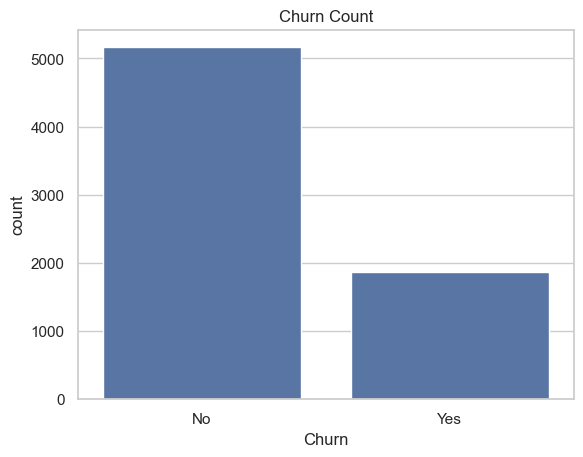

In [9]:
sns.countplot(data=df,x='Churn')
plt.title('Churn Count')
plt.show()

In [11]:
sns.boxplot(data=df,x='Churn',y='tenture')
plt.title('Tenure vs Churn')
plt.show()

sns.boxplot(data=df, x='Churn',y='MonthlyCharges')
plt.show()

ValueError: Could not interpret value `tenture` for `y`. An entry with this name does not appear in `data`.

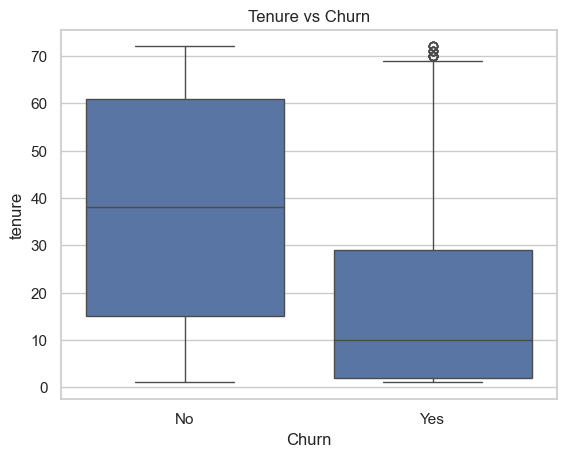

In [12]:
sns.boxplot(data=df,x='Churn',y='tenure')
plt.title('Tenure vs Churn')
plt.show()

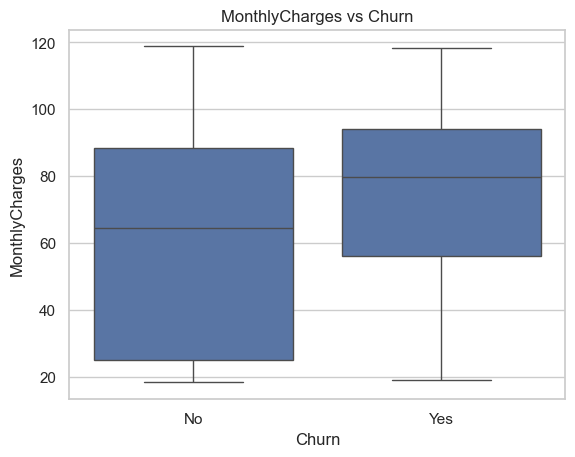

In [13]:
sns.boxplot(data=df, x='Churn', y='MonthlyCharges')
plt.title('MonthlyCharges vs Churn')
plt.show()

In [14]:
x=df.drop('Churn',axis=1)
y=df['Churn']

In [16]:
from sklearn.model_selection import train_test_split
x_train,x_test, y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

numeric_features=['tenure','MonthlyCharges','TotalCharges']
categorical_features=[col for col in x.columns if col not in numeric_features]
numeric_transformer=Pipeline(steps=[('imputer',SimpleImputer(strategy='median'))])

categorical_transformer=Pipeline(steps=[('imputer',SimpleImputer(strategy='most_frequent')),('onehot',OneHotEncoder(handle_unknown='ignore'))])

preprocess=ColumnTransformer(transformers=[('num',numeric_transformer,numeric_features),('cat',categorical_transformer,categorical_features)])

In [1]:
from sklearn.linear_model import LogisticRegression
log_reg_clf=Pipeline(steps=[('preprocess',preprocess),('model',LogisticRegression(max_iter=1000))])
log_reg_clf.fit(x_train ,y_train)

NameError: name 'Pipeline' is not defined

In [21]:
y_pred=log_reg_clf.predict(x_test)
y_proba=log_reg_clf.predict_proba(x_test)[:,1]

In [22]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,classification_report

print ("Accuracy:",accuracy_score(y_test,y_pred))
print ("Precision:",precision_score(y_test,y_pred,pos_label="Yes"))
print ("Recall:",recall_score(y_test,y_pred,pos_label="Yes"))
print ("F1-score:",f1_score(y_test,y_pred,pos_label="Yes"))

print("\nClassification Report:\n")
print(classification_report(y_test,y_pred))

Accuracy: 0.7960199004975125
Precision: 0.6260869565217392
Recall: 0.5775401069518716
F1-score: 0.6008344923504868

Classification Report:

              precision    recall  f1-score   support

          No       0.85      0.88      0.86      1033
         Yes       0.63      0.58      0.60       374

    accuracy                           0.80      1407
   macro avg       0.74      0.73      0.73      1407
weighted avg       0.79      0.80      0.79      1407



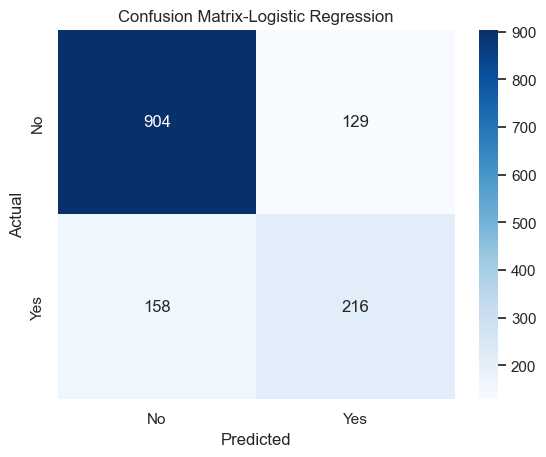

In [26]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm=confusion_matrix(y_test,y_pred,labels=["No","Yes"])
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',
            xticklabels=["No","Yes"],
            yticklabels=["No","Yes"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix-Logistic Regression")
plt.show()

In [8]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_proba= log_reg_clf.predict_proba(x_test)[:,1]
fpr,tpr,thresholds=roc_curve(y_test,y_proba,pos_label="Yes")
auc_score=roc_auc_score(y_test, y_proba)

plt.plot(fpr,tpr,label=f"Logistic Regression (AUC ={auc_score:.3f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rzte")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

NameError: name 'log_reg_clf' is not defined

In [9]:
import pandas as pd

df = pd.read_csv(r"D:\Churn_Analysis_Project\data\WA_Fn-UseC_-Telco-Customer-Churn.csv")



In [10]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna(subset=['TotalCharges'])


In [11]:
X = df.drop('Churn', axis=1)
y = df['Churn']


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_features = [col for col in X.columns if col not in numeric_features]

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocess = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)


In [14]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.pipeline import Pipeline

tree_clf = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', DecisionTreeClassifier(random_state=42))
])

tree_clf.fit(X_train, y_train)
y_pred_tree = tree_clf.predict(X_test)

print("Decision Tree")
print("Accuracy :", accuracy_score(y_test, y_pred_tree))
print("Precision:", precision_score(y_test, y_pred_tree, pos_label="Yes"))
print("Recall   :", recall_score(y_test, y_pred_tree, pos_label="Yes"))
print("F1-score :", f1_score(y_test, y_pred_tree, pos_label="Yes"))


Decision Tree
Accuracy : 0.767590618336887
Precision: 0.573208722741433
Recall   : 0.4919786096256685
F1-score : 0.5294964028776978


In [15]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

rf_clf.fit(X_train, y_train)
y_pred_rf = rf_clf.predict(X_test)

print("Random Forest")
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf, pos_label="Yes"))
print("Recall   :", recall_score(y_test, y_pred_rf, pos_label="Yes"))
print("F1-score :", f1_score(y_test, y_pred_rf, pos_label="Yes"))


Random Forest
Accuracy : 0.7860696517412935
Precision: 0.6262975778546713
Recall   : 0.4839572192513369
F1-score : 0.5460030165912518


In [4]:
log_reg_clf = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', LogisticRegression(max_iter=2000))
])
log_reg_clf.fit(X_train, y_train)


NameError: name 'Pipeline' is not defined

In [5]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression


In [6]:
log_reg_clf = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', LogisticRegression(max_iter=2000))
])
log_reg_clf.fit(X_train, y_train)


NameError: name 'preprocess' is not defined

In [7]:
import pandas as pd

df = pd.read_csv(r"D:\Churn_Analysis_Project\data\WA_Fn-UseC_-Telco-Customer-Churn.csv")

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna(subset=['TotalCharges'])


In [8]:
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_features = [col for col in X.columns if col not in numeric_features]

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocess = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)


In [10]:
from sklearn.linear_model import LogisticRegression

log_reg_clf = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', LogisticRegression(max_iter=2000))
])
log_reg_clf.fit(X_train, y_train)


C:\Users\KAALI\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred_log = log_reg_clf.predict(X_test)

print("Logistic Regression")
print("Accuracy :", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log, pos_label="Yes"))
print("Recall   :", recall_score(y_test, y_pred_log, pos_label="Yes"))
print("F1-score :", f1_score(y_test, y_pred_log, pos_label="Yes"))


Logistic Regression
Accuracy : 0.8009950248756219
Precision: 0.6366279069767442
Recall   : 0.5855614973262032
F1-score : 0.6100278551532033


In [12]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Probabilities for class "Yes"
y_proba_log  = log_reg_clf.predict_proba(X_test)[:, 1]
y_proba_tree = tree_clf.predict_proba(X_test)[:, 1]
y_proba_rf   = rf_clf.predict_proba(X_test)[:, 1]

fpr_log,  tpr_log,  _ = roc_curve(y_test, y_proba_log,  pos_label="Yes")
fpr_tree, tpr_tree, _ = roc_curve(y_test, y_proba_tree, pos_label="Yes")
fpr_rf,   tpr_rf,   _ = roc_curve(y_test, y_proba_rf,   pos_label="Yes")

auc_log  = roc_auc_score(y_test, y_proba_log)
auc_tree = roc_auc_score(y_test, y_proba_tree)
auc_rf   = roc_auc_score(y_test, y_proba_rf)

plt.figure(figsize=(6, 6))
plt.plot(fpr_log,  tpr_log,  label=f"LogReg (AUC = {auc_log:.3f})")
plt.plot(fpr_tree, tpr_tree, label=f"Decision Tree (AUC = {auc_tree:.3f})")
plt.plot(fpr_rf,   tpr_rf,   label=f"Random Forest (AUC = {auc_rf:.3f})")
plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()


NameError: name 'tree_clf' is not defined

In [13]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.pipeline import Pipeline

# Decision Tree
tree_clf = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', DecisionTreeClassifier(random_state=42))
])
tree_clf.fit(X_train, y_train)

# Random Forest
rf_clf = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])
rf_clf.fit(X_train, y_train)


,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


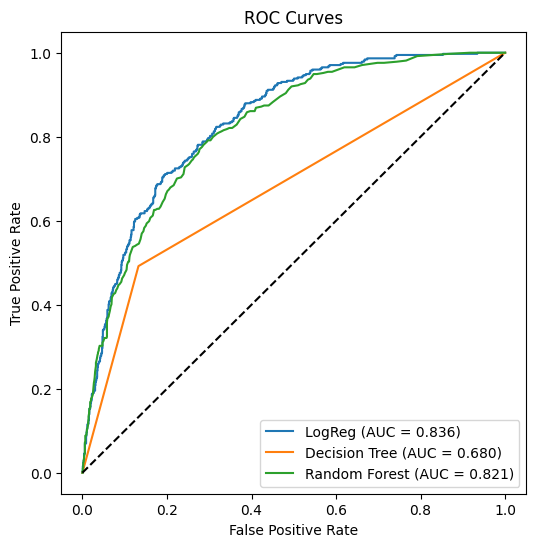

In [14]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_proba_log  = log_reg_clf.predict_proba(X_test)[:, 1]
y_proba_tree = tree_clf.predict_proba(X_test)[:, 1]
y_proba_rf   = rf_clf.predict_proba(X_test)[:, 1]

fpr_log,  tpr_log,  _ = roc_curve(y_test, y_proba_log,  pos_label="Yes")
fpr_tree, tpr_tree, _ = roc_curve(y_test, y_proba_tree, pos_label="Yes")
fpr_rf,   tpr_rf,   _ = roc_curve(y_test, y_proba_rf,   pos_label="Yes")

auc_log  = roc_auc_score(y_test, y_proba_log)
auc_tree = roc_auc_score(y_test, y_proba_tree)
auc_rf   = roc_auc_score(y_test, y_proba_rf)

plt.figure(figsize=(6, 6))
plt.plot(fpr_log,  tpr_log,  label=f"LogReg (AUC = {auc_log:.3f})")
plt.plot(fpr_tree, tpr_tree, label=f"Decision Tree (AUC = {auc_tree:.3f})")
plt.plot(fpr_rf,   tpr_rf,   label=f"Random Forest (AUC = {auc_rf:.3f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()


In [15]:
import joblib, os

os.makedirs("../models", exist_ok=True)
joblib.dump(log_reg_clf, "../models/logistic_regression_churn.joblib")


['../models/logistic_regression_churn.joblib']

In [16]:
import os
print("Models folder exists:", os.path.exists("../models"))
print("Model file exists:", os.path.exists("../models/logistic_regression_churn.joblib"))


Models folder exists: True
Model file exists: True


In [17]:
import joblib
loaded_model = joblib.load("../models/logistic_regression_churn.joblib")
prob = loaded_model.predict_proba(X_test[:1])[0, 1]
print(f"Test prediction: {prob:.1%}")


Test prediction: 1.4%
